<a href="https://colab.research.google.com/github/DHAMU2563/MNIST-HANDWRITTEN-DIGIT-CLASSIFICATION/blob/main/DEEP_LASSIGNMENT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Training Images:", x_train.shape)
print("Training Labels:", y_train.shape)
print("Testing Images:", x_test.shape)
print("Testing Labels:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images: (60000, 28, 28)
Training Labels: (60000,)
Testing Images: (10000, 28, 28)
Testing Labels: (10000,)


In [ ]:
print("Classes:", np.unique(y_train))
print("Number of Classes:", len(np.unique(y_train)))
print("Minimum Pixel Value:", x_train.min())
print("Maximum Pixel Value:", x_train.max())

Classes: [0 1 2 3 4 5 6 7 8 9]
Number of Classes: 10
Minimum Pixel Value: 0
Maximum Pixel Value: 255


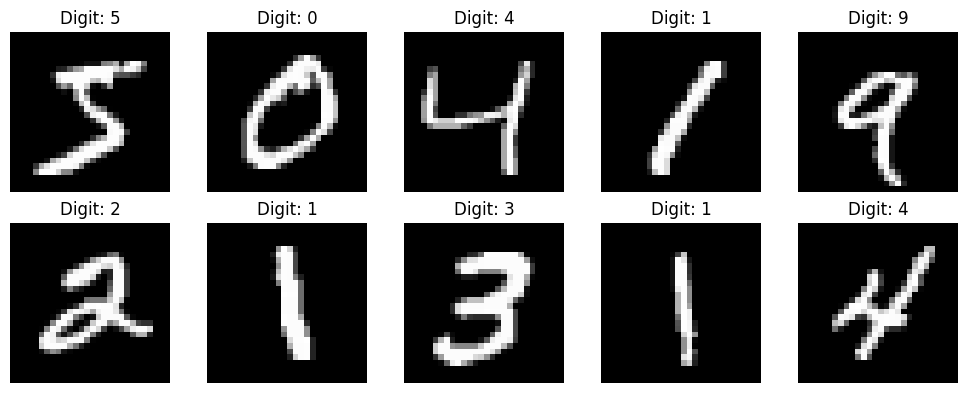

In [ ]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Digit: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
model = keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.20),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.10
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7375 - loss: 3.6692 - val_accuracy: 0.8775 - val_loss: 0.4782
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8433 - loss: 0.6443 - val_accuracy: 0.9202 - val_loss: 0.3237
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8726 - loss: 0.4847 - val_accuracy: 0.9252 - val_loss: 0.2815
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8932 - loss: 0.4129 - val_accuracy: 0.9357 - val_loss: 0.2524
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9046 - loss: 0.3581 - val_accuracy: 0.9483 - val_loss: 0.2026
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9124 - loss: 0.3350 - val_accuracy: 0.9497 - val_loss: 0.2017
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9172 - loss: 0.3082 - val_accuracy: 0.9483 - val_loss: 0.2080
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9256 - loss: 0.2867 - val_accuracy: 0

In [ ]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy * 100, "%")

Test Loss: 0.20695988833904266
Test Accuracy: 94.91999745368958 %


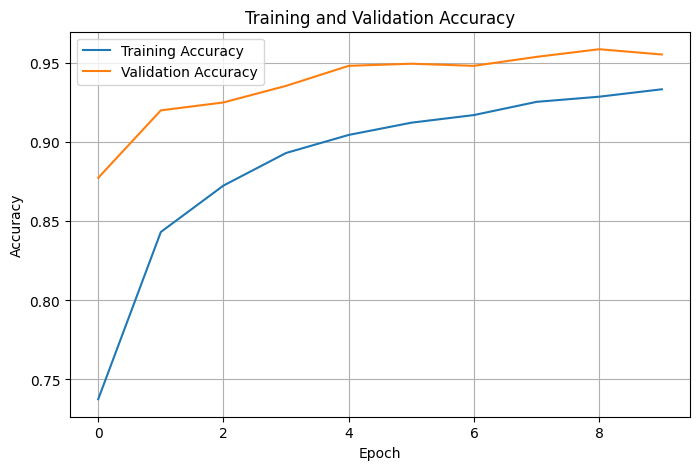

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

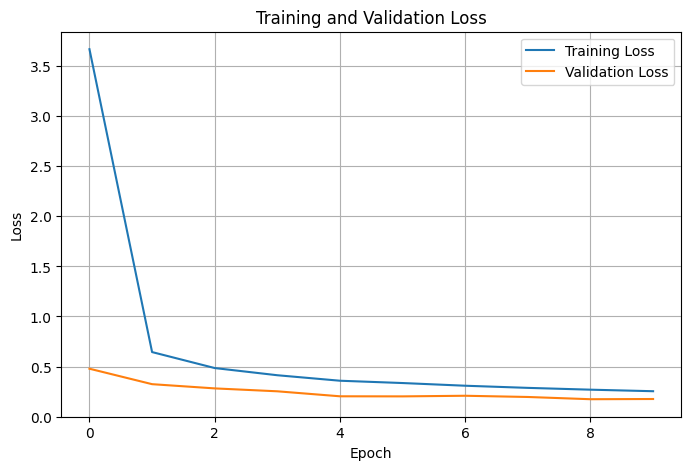

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
sample_images = x_test[:5]
sample_labels = y_test[:5]

predictions = model.predict(sample_images, verbose=0)
predicted_labels = np.argmax(predictions, axis=1)

for i in range(5):
    print(
        f"Image {i+1}: "
        f"Actual = {sample_labels[i]}, "
        f"Predicted = {predicted_labels[i]}"
    )

Image 1: Actual = 7, Predicted = 7
Image 2: Actual = 2, Predicted = 2
Image 3: Actual = 1, Predicted = 1
Image 4: Actual = 0, Predicted = 0
Image 5: Actual = 4, Predicted = 4


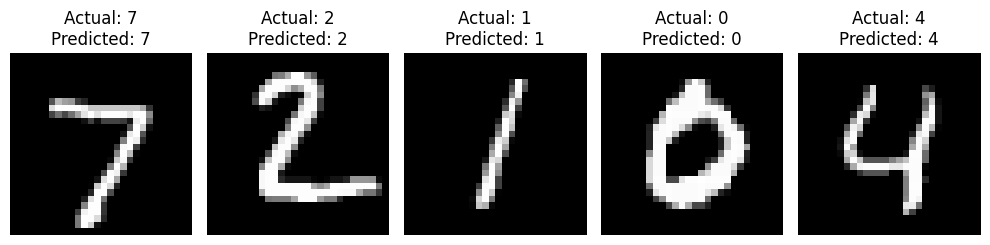

In [ ]:
plt.figure(figsize=(10, 4))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(sample_images[i], cmap="gray")
    plt.title(
        f"Actual: {sample_labels[i]}\n"
        f"Predicted: {predicted_labels[i]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
correct = np.sum(predicted_labels == sample_labels)
total = len(sample_labels)

sample_accuracy = (correct / total) * 100

print("Correct Predictions:", correct)
print("Total Predictions:", total)
print("Sample Accuracy:", sample_accuracy, "%")

Correct Predictions: 5
Total Predictions: 5
Sample Accuracy: 100.0 %


In [ ]:
experimental_model = keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.20),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

experimental_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
experimental_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
experimental_history = experimental_model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.10
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.8238 - loss: 3.5803 - val_accuracy: 0.9245 - val_loss: 0.4073
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8927 - loss: 0.6269 - val_accuracy: 0.9403 - val_loss: 0.2660
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9158 - loss: 0.3794 - val_accuracy: 0.9555 - val_loss: 0.2017
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9309 - loss: 0.2856 - val_accuracy: 0.9587 - val_loss: 0.1675
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9394 - loss: 0.2352 - val_accuracy: 0.9605 - val_loss: 0.1627
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9466 - loss: 0.2046 - val_accuracy: 0.9632 - val_loss: 0.1470
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9515 - loss: 0.1812 - val_accuracy: 0.9670 - val_loss: 0.1369
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9551 - loss: 0.1609 - val_accurac

In [ ]:
experimental_loss, experimental_accuracy = experimental_model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Experimental Test Loss:", experimental_loss)
print(
    "Experimental Test Accuracy:",
    experimental_accuracy * 100,
    "%"
)

Experimental Test Loss: 0.14275698363780975
Experimental Test Accuracy: 96.42000198364258 %


In [ ]:
original_accuracy = test_accuracy * 100
new_accuracy = experimental_accuracy * 100

print("Original Model Accuracy:", original_accuracy, "%")
print("Experimental Model Accuracy:", new_accuracy, "%")
print(
    "Improvement:",
    new_accuracy - original_accuracy,
    "percentage points"
)

Original Model Accuracy: 94.91999745368958 %
Experimental Model Accuracy: 96.42000198364258 %
Improvement: 1.500004529953003 percentage points


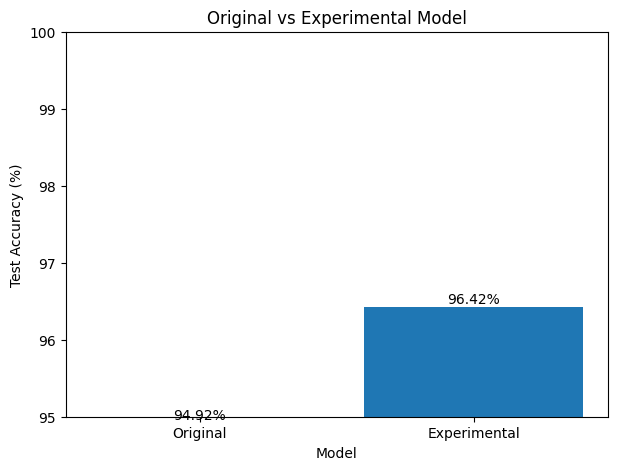

In [ ]:
models = ["Original", "Experimental"]
accuracies = [original_accuracy, new_accuracy]

plt.figure(figsize=(7, 5))

plt.bar(models, accuracies)

plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")
plt.title("Original vs Experimental Model")
plt.ylim(95, 100)

for i, value in enumerate(accuracies):
    plt.text(i, value + 0.05, f"{value:.2f}%", ha="center")

plt.show()

In [ ]:
model.save("mnist_digit_model.keras")

print("Model saved successfully.")

Model saved successfully.
